# Avence 1:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargamos el csv
df = pd.read_csv('data_latinoamerica.csv', low_memory=False)


In [3]:
# devuelve (filas, columnas)
dimensiones = df.shape

print(f"El dataset tiene {dimensiones[0]} filas y {dimensiones[1]} columnas.")

df.head(3)

El dataset tiene 12216057 filas y 50 columnas.


,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
0,AR,2020-01-01,AR,Argentina,3.0,0.0,3.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
1,AR,2020-01-02,AR,Argentina,14.0,0.0,17.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
2,AR,2020-01-03,AR,Argentina,3.0,0.0,20.0,0.0,NaN,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN


In [4]:
# Lista países objetivo
lista_codigos = ['AR', 'BR', 'CL', 'CO', 'MX', 'PE']

# Usamos .copy() para trabajar limpio en memoria
df_filtrado = df[df['country_code'].isin(lista_codigos)].copy()

print(f"Filas después de filtrar países: {df_filtrado.shape[0]}")

# Convertimos la fecha 
df_filtrado['date'] = pd.to_datetime(df_filtrado['date'])

# Filtramos por fecha > 2021-01-01
df_final = df_filtrado[df_filtrado['date'] > '2021-01-01'].copy()

# Reiniciamos el índice
df_final.reset_index(drop=True, inplace=True)

print("-" * 30)
print(f"Filas finales: {df_final.shape[0]}")
df_final.head()

Filas después de filtrar países: 11970289
------------------------------
Filas finales: 7537296


,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
0,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
1,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
2,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
3,AR,2021-01-05,AR,Argentina,14085.0,160.0,1703606.0,47162.0,29852.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN
4,AR,2021-01-06,AR,Argentina,14496.0,131.0,1718102.0,47293.0,34162.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,NaN,NaN


In [6]:
# Nulos y tipos de datos

df_final.info()
print("-" * 30)

# Calculamos cuántos nulos hay por columna
nulos = df_final.isnull().sum()

# Calculamos el porcentaje de nulos 
porcentaje_nulos = (nulos / len(df_final)) * 100

# columnas problemáticas
resumen_nulos = pd.DataFrame({
    'Cantidad Nulos': nulos,
    '% Faltante': porcentaje_nulos
})

# Filtramos para mostrar solo las que tienen algún nulo
nulos_visibles = resumen_nulos[resumen_nulos['Cantidad Nulos'] > 0].sort_values(by='% Faltante', ascending=False)

print("\nCOLUMNAS CON DATOS FALTANTES:")
print(nulos_visibles)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537296 entries, 0 to 7537295
Data columns (total 50 columns):
 #   Column                                 Dtype         
---  ------                                 -----         
 0   location_key                           object        
 1   date                                   datetime64[ns]
 2   country_code                           object        
 3   country_name                           object        
 4   new_confirmed                          float64       
 5   new_deceased                           float64       
 6   cumulative_confirmed                   float64       
 7   cumulative_deceased                    float64       
 8   cumulative_vaccine_doses_administered  float64       
 9   population                             float64       
 10  population_male                        float64       
 11  population_female                      float64       
 12  population_rural                       float64       
 1

LIMPIEZA

In [16]:
# Población y Clima: Rellenamos con la MEDIANA de cada país
cols_rellenar_mediana = ['population', 'average_temperature_celsius']

# Usamos función de orden superior
for col in cols_rellenar_mediana:
    df_final[col] = df_final.groupby('country_code')[col].transform(lambda x: x.fillna(x.median()))

# Casos y Muertes: Rellenamos con 0
# Asumimos que si no hay dato, ese día no hubo reporte o fue 0
cols_rellenar_cero = ['new_confirmed', 'new_deceased','new_recovered']
df_final[cols_rellenar_cero] = df_final[cols_rellenar_cero].fillna(0)


# Borrado de filas sin población o sin fecha si las hubiera
df_final.dropna(subset=['population', 'date'], inplace=True)

ARCHIVO FILTRADO Y LIMPIO

In [17]:
# Guardado del Archivo Limpio 
df_final.to_csv('DatosFinalesFiltrado.csv', index=False)


Nulos en 'population' ahora: 0
Nulos en 'new_confirmed' ahora: 0


ANÁLISIS Y ESTADÍSTICA

In [19]:
# Elegimos una mezcla de columnas numéricas y categóricas para ver la diferencia
columnas_interes = ['new_confirmed', 'new_deceased', 'new_recovered', 'population', 'average_temperature_celsius', 'country_name']

for col in columnas_interes:
    print(f"\nANÁLISIS DE LA COLUMNA: '{col}'")
    print("-" * 30)
    
    # Calculamos estadísticas numéricas
    try:
        # describe(): métricas automáticas según el tipo de dato
        stats = df_final[col].describe() 
        print(stats)
    except:
        print("No se pudieron calcular estadísticas para esta columna.")


ANÁLISIS DE LA COLUMNA: 'new_confirmed'
------------------------------
count    7.537296e+06
mean     2.007126e+01
std      6.713224e+02
min     -7.390700e+04
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      2.984080e+05
Name: new_confirmed, dtype: float64

ANÁLISIS DE LA COLUMNA: 'new_deceased'
------------------------------
count    7.537296e+06
mean     3.798983e-01
std      1.449197e+01
min     -4.109000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.144700e+04
Name: new_deceased, dtype: float64

ANÁLISIS DE LA COLUMNA: 'new_recovered'
------------------------------
count    7.537296e+06
mean     5.160811e+00
std      5.481633e+02
min     -3.111900e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.829570e+05
Name: new_recovered, dtype: float64

ANÁLISIS DE LA COLUMNA: 'population'
------------------------------
count    7.537296e+06
mean     1.162959e+05
std      2.377398e+06
min      4.0000

In [ ]:
# Columnas que no deberían tener números negativos
cols_a_corregir = ['new_confirmed', 'new_deceased', 'new_recovered']

for col in cols_a_corregir:
    # Verificamos si la columna existe en tu tabla
    if col in df_final.columns:
        # Contamos cuántos negativos hay antes de arreglar
        negativos = (df_final[col] < 0).sum()
        
        if negativos > 0:
            print(f"🔧 Se encontraron {negativos} valores negativos en '{col}'. Reemplazando por 0...")
            # buscamos en el archivo los negativos y ahí les ponemos 0
            df_final.loc[df_final[col] < 0, col] = 0
        else:
            print(f"La columna '{col}' no tiene negativos")


La columna 'new_confirmed' no tiene negativos
La columna 'new_deceased' no tiene negativos
La columna 'new_recovered' no tiene negativos


In [23]:
# Función Personalizada de Estadísticas 
def calcular_metricas_extra(dataframe, columna):
    """
    Calcula y devuelve la mediana, la varianza y el rango de una columna específica.
    """
    serie = dataframe[columna]
    
    # Mediana: El valor central
    mediana = serie.median()
    
    # Varianza: Qué tan dispersos están los datos respecto a la media
    varianza = serie.var()
    
    # Rango: La distancia entre el mínimo y el máximo absoluto
    rango = serie.max() - serie.min()
    
    return mediana, varianza, rango

# Usamos 'new_confirmed' porque es vital para saber la volatilidad del virus
variable_prueba = 'new_confirmed'

med, var, ran = calcular_metricas_extra(df_final, variable_prueba)

print(f"ANÁLISIS DE LA VARIABLE: {variable_prueba.upper()} ")
print(f"Mediana: {med:,.2f} casos")
print(f"Varianza: {var:,.2f}")
print(f"Rango: {ran:,.2f} (Diferencia entre el día con más casos y el de menos)")

ANÁLISIS DE LA VARIABLE: NEW_CONFIRMED 
Mediana: 0.00 casos
Varianza: 445,388.93
Rango: 298,408.00 (Diferencia entre el día con más casos y el de menos)


In [ ]:
# GUARDAR
nombre_archivo = 'DatosFinalesFiltrado.csv'

df_final.to_csv(nombre_archivo, index=False)



Archivo guardado exitosamente como: DatosFinalesFiltrado.csv


# Avance 2: Análisis exploratorio y visualización

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Cargamos el archivo limpio
df_final = pd.read_csv('DatosFinalesFiltrado.csv')

# convertimos el formato fecha
df_final['date'] = pd.to_datetime(df_final['date'])

print(f"Filas: {df_final.shape[0]}, Columnas: {df_final.shape[1]}")
df_final.head(3)

Filas: 7537296, Columnas: 50


,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
0,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,NaN
1,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,NaN
2,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,NaN


ANÁLISIS ESTADÍSTICO

In [4]:
# Por país y calculamos media y desvío estándar de los casos nuevos y fallecidos.
resumen_paises = df_final.groupby('country_name')[['new_confirmed', 'new_deceased']].agg(['mean', 'std', 'max'])

print("RESUMEN ESTADÍSTICO POR PAÍS")
print(resumen_paises)

# Relación entre variables (correlación)
# columnas numéricas clave
cols_corr = ['new_confirmed', 'new_deceased', 'population', 'average_temperature_celsius']
matriz_correlacion = df_final[cols_corr].corr()

print("\n MATRIZ DE CORRELACIÓN")
print(matriz_correlacion)

RESUMEN ESTADÍSTICO POR PAÍS
             new_confirmed                        new_deceased             \
                      mean          std       max         mean        std   
country_name                                                                
Argentina        66.359833  1252.293560  174174.0     0.717522  10.211377   
Brazil           24.936409   834.141048  298408.0     0.469629  17.328840   
Chile            52.066853   523.931038   38446.0     0.653709  27.793669   
Colombia         17.536033   384.860360   40415.0     0.451025   8.703016   
Mexico            7.352278   309.308470   81002.0     0.144686   8.744600   
Peru              6.446114   235.366255   58128.0     0.291115   8.118180   

                       
                  max  
country_name           
Argentina       656.0  
Brazil         4249.0  
Chile         11447.0  
Colombia        716.0  
Mexico         1495.0  
Peru            847.0  

 MATRIZ DE CORRELACIÓN
                             new_conf

C:\Users\melanie\AppData\Local\Temp\ipykernel_17800\2263482094.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_totales, x='new_confirmed', y='country_name', palette='viridis', ax=ax[0])
C:\Users\melanie\AppData\Local\Temp\ipykernel_17800\2263482094.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datos_muertes, x='new_deceased', y='country_name', palette='magma', ax=ax[1])


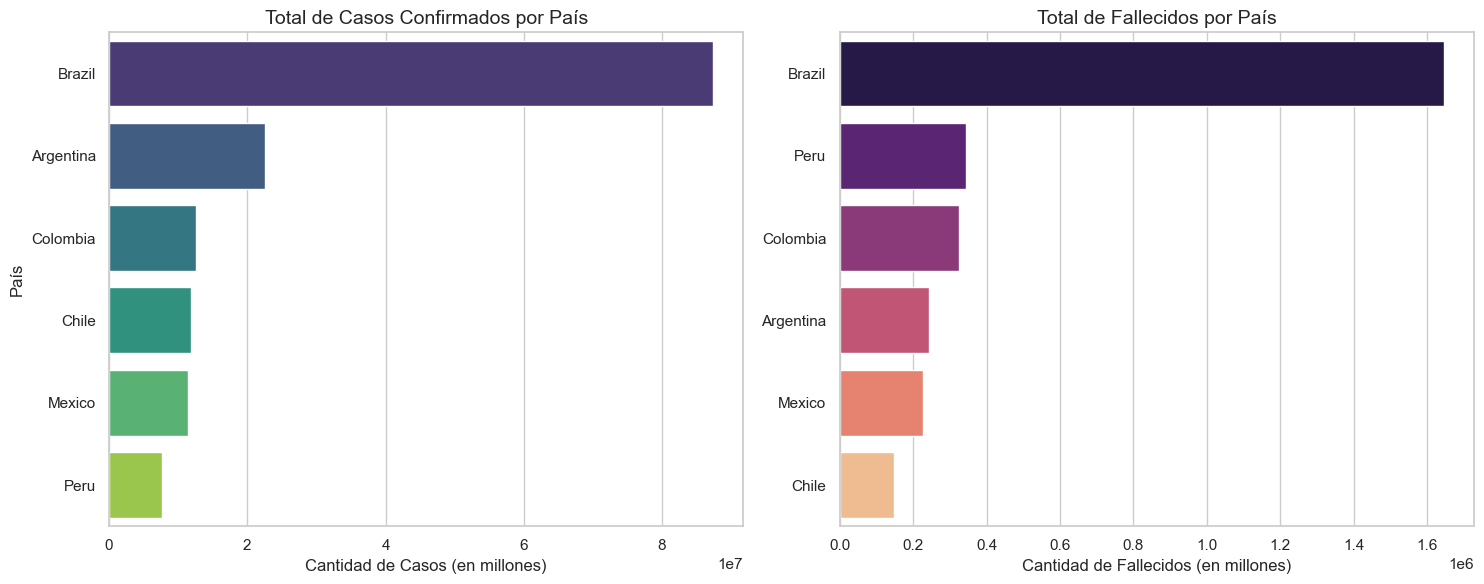

In [5]:
# Total casos confirmados y fallecidos por país
datos_totales = df_final.groupby('country_name')[['new_confirmed', 'new_deceased']].sum().reset_index()

# Ordenamos
datos_totales = datos_totales.sort_values('new_confirmed', ascending=False)

# Dos gráficos
fig, ax = plt.subplots(1, 2, figsize=(15, 6)) 

# Total de Casos Confirmados
sns.barplot(data=datos_totales, x='new_confirmed', y='country_name', palette='viridis', ax=ax[0])
ax[0].set_title('Total de Casos Confirmados por País', fontsize=14)
ax[0].set_xlabel('Cantidad de Casos (en millones)')
ax[0].set_ylabel('País')


# Ordenamos 
datos_muertes = datos_totales.sort_values('new_deceased', ascending=False)

# Total de Fallecidos
sns.barplot(data=datos_muertes, x='new_deceased', y='country_name', palette='magma', ax=ax[1])
ax[1].set_title('Total de Fallecidos por País', fontsize=14)
ax[1].set_xlabel('Cantidad de Fallecidos (en millones)')
ax[1].set_ylabel('') 

plt.tight_layout()
plt.show()

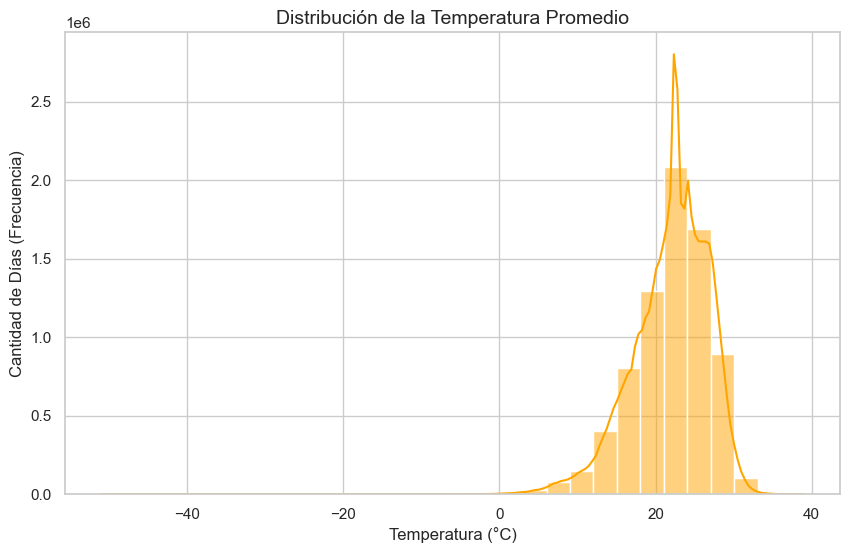

In [ ]:
# Histograma de Temperatura 
plt.figure()

# bins=30 significa "dividí los datos en 30 barritas"
sns.histplot(data=df_final, x='average_temperature_celsius', bins=30, kde=True, color='orange')

plt.title('Distribución de la Temperatura Promedio', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Cantidad de Días (Frecuencia)')

plt.show()

##### eje y: cantidad de veces que se repitio la temperatura en la base de datos.
##### Analizamos una sola variable => la temperatura.
##### Este grafico busca entender el entorno operativo. Prevalece temperaturas de 20 a 25 °C en su mayoria por lo que es importante a la hora de su logistica mantener su cadena de Frio.

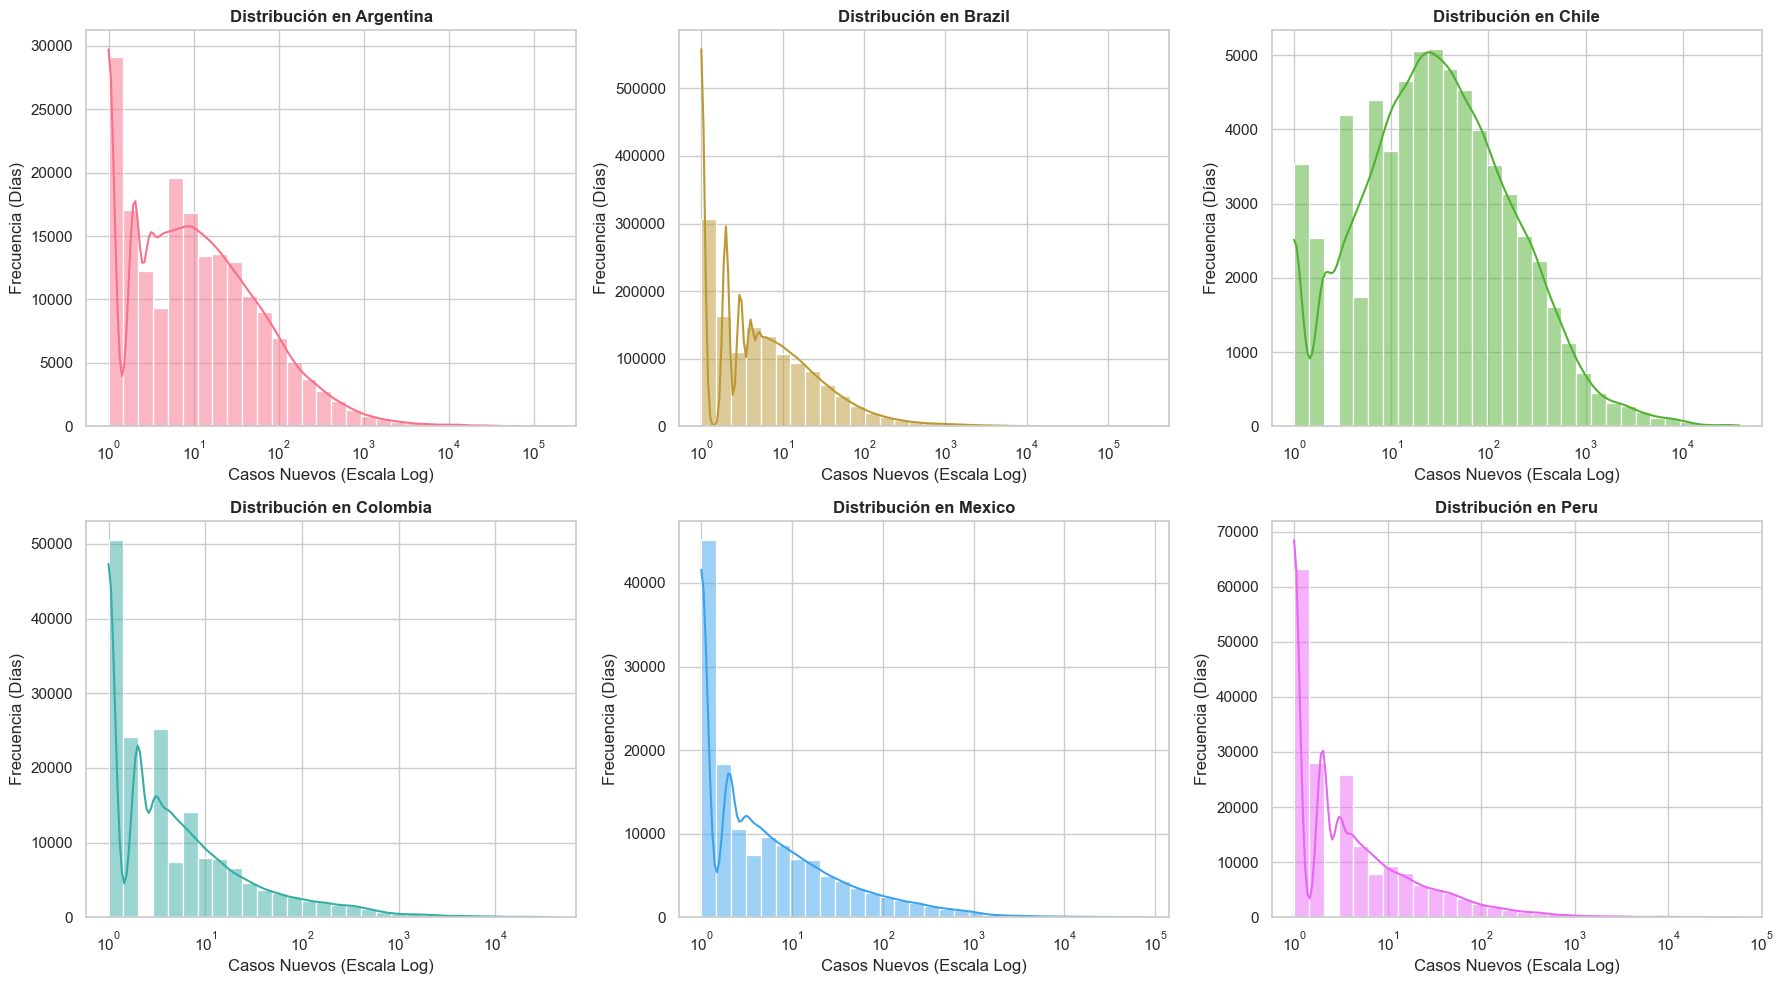

In [6]:
# Histogramas por País 
lista_paises = ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'Peru']

# Configuramos el lienzo grande (2 filas, 3 columnas)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, pais in enumerate(lista_paises):
    
    # Filtramos: País actual y sacamos los ceros
    data_pais = df_final[(df_final['country_name'] == pais) & (df_final['new_confirmed'] > 0)]
    
    # Elegimos color
    color = sns.color_palette("husl", 6)[i]
    
    sns.histplot(
        data=data_pais, 
        x='new_confirmed', 
        bins=30, 
        kde=True, 
        color=color, 
        log_scale=True,
        ax=axes[i]
    )
    
    # descripcion en graf
    axes[i].set_title(f'Distribución en {pais}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Casos Nuevos (Escala Log)')
    axes[i].set_ylabel('Frecuencia (Días)')

plt.tight_layout()
plt.show()

##### Se observa que CO, MX y PR tuvieron muchos dias con pocos casos y pocos dias con muchos casos.
##### CH es un pais que se mantuvo casi siempre en un promedio cte. 

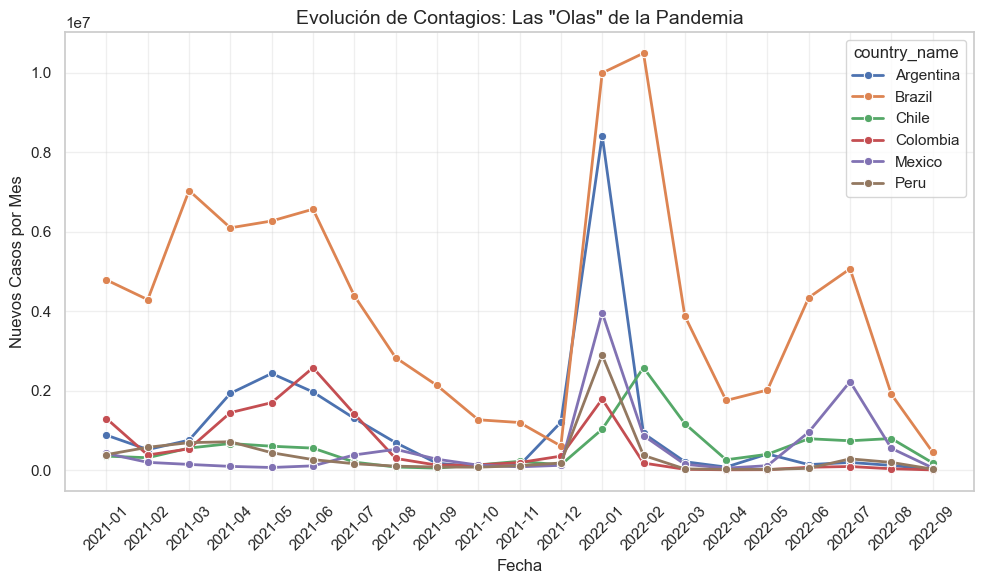

In [ ]:
# Evolución de Casos por Mes 
lista_paises = sorted(df_final['country_name'].unique())
paleta_fija = 'tab10'

plt.figure()

# Creamos una columna "Año-Mes"
df_evolucion = df_final.copy()
df_evolucion['mes_anio'] = df_evolucion['date'].dt.to_period('M').astype(str)

# Agrupamos: Sumamos los casos de cada país por mes
datos_grafico = df_evolucion.groupby(['mes_anio', 'country_name'])['new_confirmed'].sum().reset_index()

# Dibujamos las Líneas
sns.lineplot(
    data=datos_grafico, 
    x='mes_anio', 
    y='new_confirmed', 
    hue='country_name', 
    marker='o',       #  puntito en cada mes
    linewidth=2       # Línea más gruesa
)

plt.title('Evolución de Contagios: Las "Olas" de la Pandemia', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Nuevos Casos por Mes')


plt.xticks(rotation=45) 
plt.grid(True, alpha=0.3) # cuadrícula suave

plt.tight_layout()
plt.show()

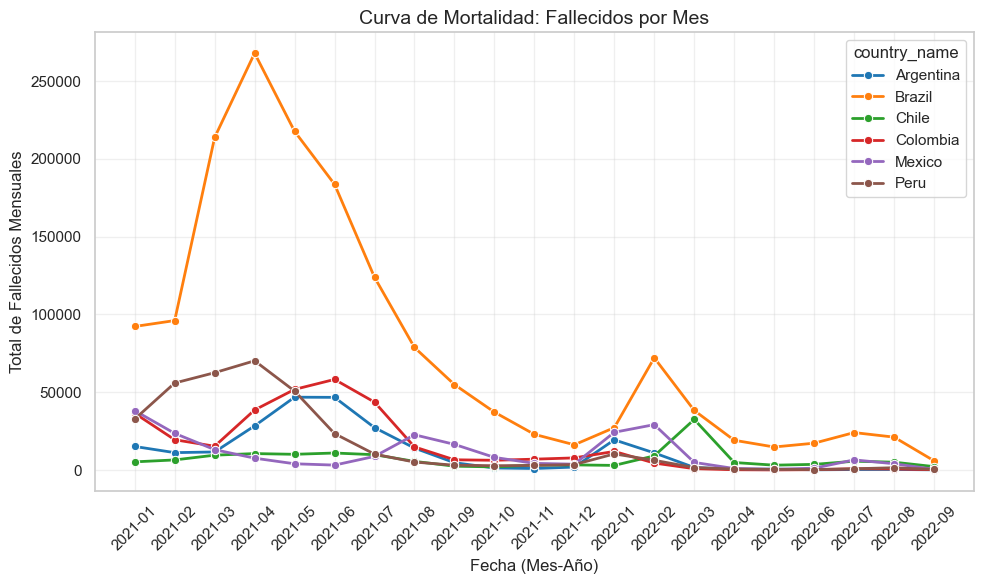

In [ ]:
# Evolución de Fallecidos por Mes 
lista_paises = sorted(df_final['country_name'].unique())
paleta_fija = 'tab10'

plt.figure()


df_muertes = df_final.copy()
# foramto año-mes
df_muertes['mes_anio'] = df_muertes['date'].dt.to_period('M').astype(str)

# Suma muertes de cada país por mes
datos_grafico = df_muertes.groupby(['mes_anio', 'country_name'])['new_deceased'].sum().reset_index()


sns.lineplot(
    data=datos_grafico, 
    x='mes_anio', 
    y='new_deceased', 
    hue='country_name', 
    hue_order=lista_paises, 
    palette=paleta_fija,
    marker='o',       
    linewidth=2
    
)

plt.title('Curva de Mortalidad: Fallecidos por Mes', fontsize=14)
plt.xlabel('Fecha (Mes-Año)')
plt.ylabel('Total de Fallecidos Mensuales')

plt.xticks(rotation=45) 
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\melanie\AppData\Local\Temp\ipykernel_17800\1551035152.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


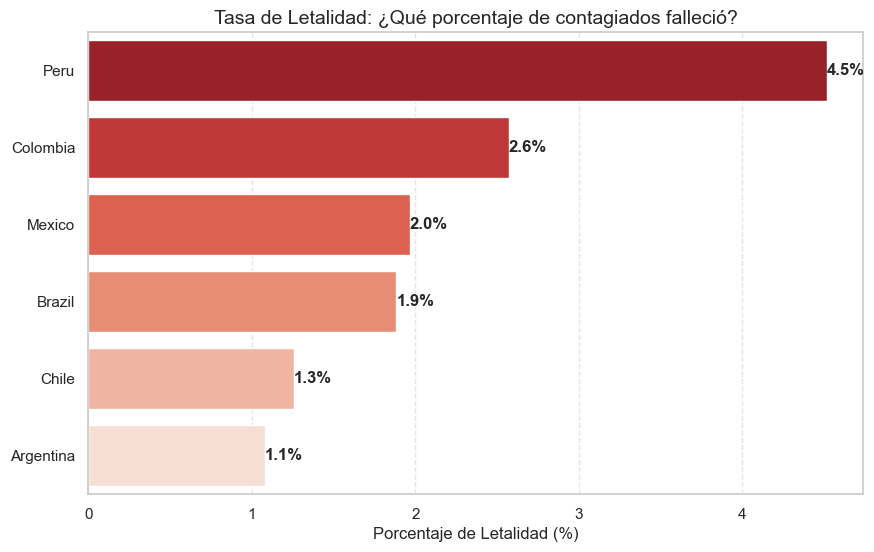

In [8]:
# Tasa de Letalidad por País

# Totales
df_totales = df_final.groupby('country_name')[['new_confirmed', 'new_deceased']].sum().reset_index()

# Tasa: (Muertos / Contagiados) * 100
df_totales['tasa_letalidad'] = (df_totales['new_deceased'] / df_totales['new_confirmed']) * 100

# Ordenamos de mayor a menor peligro
df_totales = df_totales.sort_values('tasa_letalidad', ascending=False)

# Graficamos
plt.figure()
sns.barplot(
    data=df_totales, 
    x='tasa_letalidad', 
    y='country_name', 
    palette='Reds_r' # Rojo intenso = Más letal
)

plt.title('Tasa de Letalidad: ¿Qué porcentaje de contagiados falleció?', fontsize=14)
plt.xlabel('Porcentaje de Letalidad (%)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Agregamos el número al final de la barra para que se vea claro
for index, value in enumerate(df_totales['tasa_letalidad']):
    plt.text(value, index, f'{value:.1f}%', va='center', fontweight='bold')

plt.show()

# Avence 3

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
# Cargamos el archivo limpio
df_final = pd.read_csv('DatosFinalesFiltrado.csv')

# convertimos el formato fecha
df_final['date'] = pd.to_datetime(df_final['date'])

print(f"Filas: {df_final.shape[0]}, Columnas: {df_final.shape[1]}")
df_final.head(3)

Filas: 7537296, Columnas: 50


,location_key,date,country_code,country_name,new_confirmed,new_deceased,cumulative_confirmed,cumulative_deceased,cumulative_vaccine_doses_administered,population,...,population_largest_city,area_rural_sq_km,area_urban_sq_km,life_expectancy,adult_male_mortality_rate,adult_female_mortality_rate,pollution_mortality_rate,comorbidity_mortality_rate,new_recovered,cumulative_recovered
0,AR,2021-01-02,AR,Argentina,7767.0,166.0,1670634.0,46688.0,20334.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,NaN
1,AR,2021-01-03,AR,Argentina,4934.0,157.0,1675568.0,46845.0,20529.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,NaN
2,AR,2021-01-04,AR,Argentina,13953.0,157.0,1689521.0,47002.0,25164.0,44938712.0,...,15057273.0,2690269.0,55032.0,76.52,147.086,79.483,26.6,15.8,0.0,NaN


In [10]:
# la fecha debe ser el índice
# Creamos una copia 
df_macro = df_final.set_index('date').copy()


In [12]:
#columnas a analizar
cols_a_analizar = ['new_confirmed', 'new_deceased']

# analisis mensual
#resample agrupa por periodo de tiempo, en este caso MES
df_mensual = df_macro[cols_a_analizar].resample('ME').sum()

print(" TENDENCIA MENSUAL (Top 3 Meses con más contagios)")
print(df_mensual.sort_values('new_confirmed', ascending=False).head(3))

# Comparacion ultimos 6 meses, un mes contra el anterior
df_mensual['cambio_porcentual'] = df_mensual['new_confirmed'].pct_change() * 100
print("\nEjemplo de evolución (últimos 6 meses):")
print(df_mensual[['new_confirmed', 'cambio_porcentual']].tail(6))

# ANÁLISIS trimestral
df_trimestral= df_macro[cols_a_analizar].resample('QE').sum() 
print("\n EVOLUCIÓN POR TRIMESTRE ")
print(df_trimestral)

#  ANÁLISIS ANUAL 
df_anual = df_macro[cols_a_analizar].resample('YE').sum()

print("\nRESUMEN ANUAL")
print(df_anual)

#  PROMEDIO DE CASOS POR MES 
df_final['mes_numero'] = df_final['date'].dt.month_name()

orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

estacionalidad_mes = df_final.groupby('mes_numero')['new_confirmed'].mean().reindex(orden_meses)

print("\n ESTACIONALIDAD: ¿Cuál es el mes más peligroso? ")
print("Mes con mayor promedio de casos históricos:", estacionalidad_mes.idxmax())
print(estacionalidad_mes)

 TENDENCIA MENSUAL (Top 3 Meses con más contagios)
            new_confirmed  new_deceased
date                                   
2022-01-31     28092293.0       96174.0
2022-02-28     15417558.0      132116.0
2021-06-30     12035779.0      326172.0

Ejemplo de evolución (últimos 6 meses):
            new_confirmed  cambio_porcentual
date                                        
2022-04-30      2164020.0         -60.332747
2022-05-31      2959031.0          36.737692
2022-06-30      6344306.0         114.404851
2022-07-31      8599891.0          35.552904
2022-08-31      3596964.0         -58.174307
2022-09-30       735744.0         -79.545417

 EVOLUCIÓN POR TRIMESTRE 
            new_confirmed  new_deceased
date                                   
2021-03-31     24111877.0      758692.0
2021-06-30     34495079.0     1130896.0
2021-09-30     15200482.0      452867.0
2021-12-31      6331918.0      135233.0
2022-03-31     48965283.0      308013.0
2022-06-30     11467357.0       68248.0
2

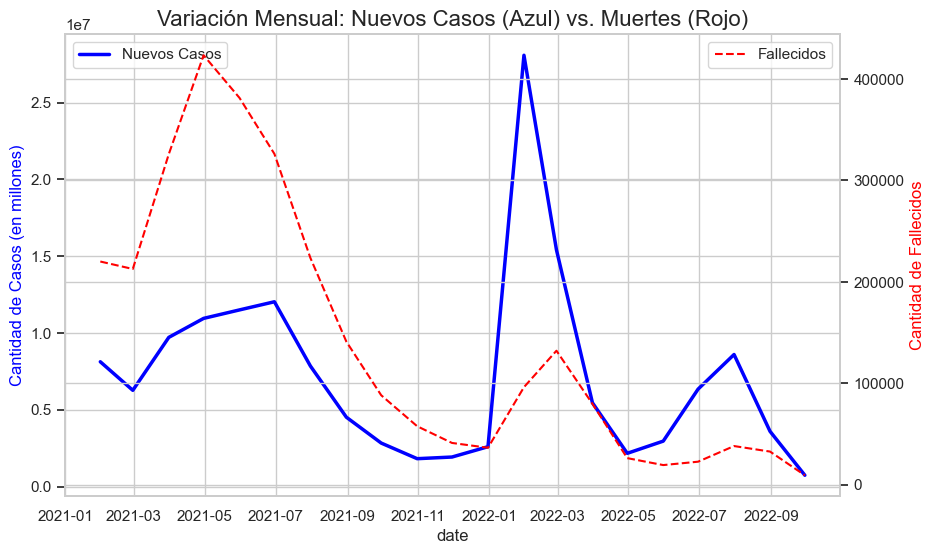

Se observa como las curvas se separan en 2022. Muchos casos (azul) pero pocas muertes (rojo).


In [ ]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# EVOLUCIÓN MENSUAL 
df_mensual = df_final.set_index('date')[['new_confirmed', 'new_deceased']].resample('ME').sum()

plt.figure()
# Creamos un gráfico de doble eje (Casos a la izquierda, Muertes a la derecha)
ax1 = sns.lineplot(data=df_mensual, x=df_mensual.index, y='new_confirmed', color='blue', label='Nuevos Casos', linewidth=2.5)
ax2 = ax1.twinx() # Segundo eje Y
sns.lineplot(data=df_mensual, x=df_mensual.index, y='new_deceased', color='red', ax=ax2, label='Fallecidos', linestyle='--')

ax1.set_title('Variación Mensual: Nuevos Casos (Azul) vs. Muertes (Rojo)', fontsize=16)
ax1.set_ylabel('Cantidad de Casos (en millones)', color='blue')
ax2.set_ylabel('Cantidad de Fallecidos', color='red')
ax1.legend(loc='upper left')
plt.show()

##### se obsserva como las curvas se separan en 2022, muchos casos(azul) pero pocas muertes(rojo).

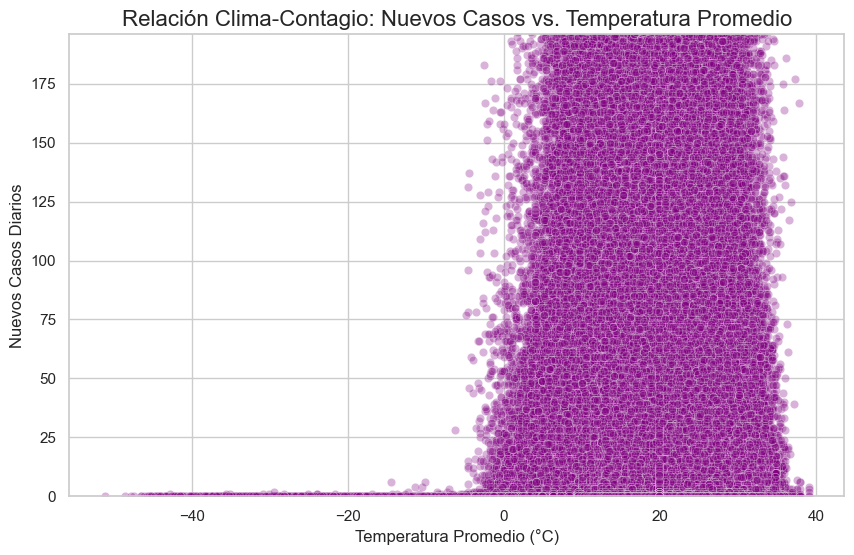

In [14]:
# ¿El virus prefiere el frío?
plt.figure()
sns.scatterplot(data=df_final, x='average_temperature_celsius', y='new_confirmed', alpha=0.3, color='purple')

plt.title('Relación Clima-Contagio: Nuevos Casos vs. Temperatura Promedio', fontsize=16)
plt.xlabel('Temperatura Promedio (°C)')
plt.ylabel('Nuevos Casos Diarios')

# Limitamos el eje Y para ver mejor la "nube" de puntos 
plt.ylim(0, df_final['new_confirmed'].quantile(0.99)) 
plt.show()


##### No existe correlacion lineal clara entre la temperatura promedio y los contagios, hay contagios masivos en climas frescos 5°C como en tropicales 30°C
##### La densidad poblacional y el comportamiento social pesan mas que la temperatura.

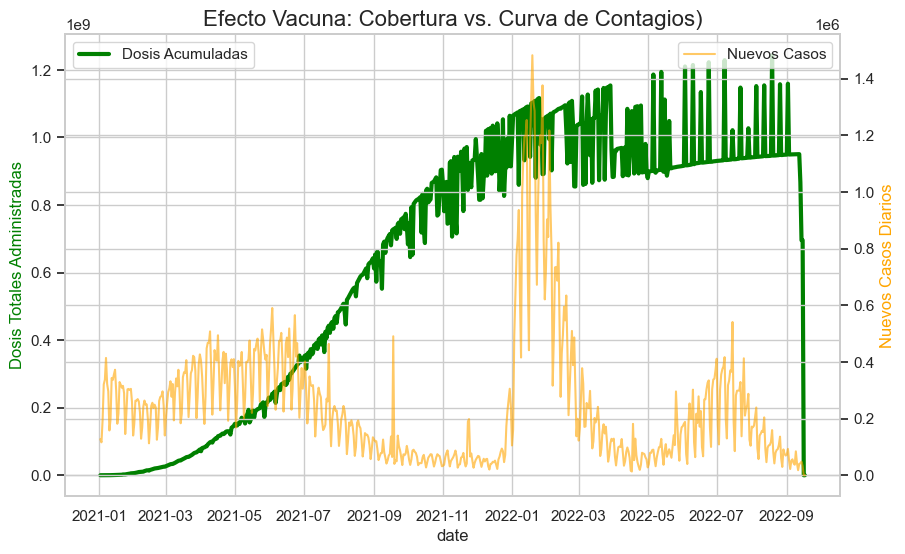

In [15]:
# Agrupamos por fecha para ver el progreso total en Latam
df_vacunas = df_final.groupby('date')[['new_confirmed', 'cumulative_vaccine_doses_administered']].sum()

plt.figure()
ax1 = sns.lineplot(data=df_vacunas, x=df_vacunas.index, y='cumulative_vaccine_doses_administered', color='green', label='Dosis Acumuladas', linewidth=3)
ax2 = ax1.twinx()
sns.lineplot(data=df_vacunas, x=df_vacunas.index, y='new_confirmed', color='orange', ax=ax2, label='Nuevos Casos', alpha=0.6)

ax1.set_title('Efecto Vacuna: Cobertura vs. Curva de Contagios)', fontsize=16)
ax1.set_ylabel('Dosis Totales Administradas', color='green')
ax2.set_ylabel('Nuevos Casos Diarios', color='orange')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

##### El pico que se dio de 2022-ene a 2022-mar se pudo haber dado a la nueva variante Ómicron, la cual evadia parcialmente la inmunidad de las vacunas. 

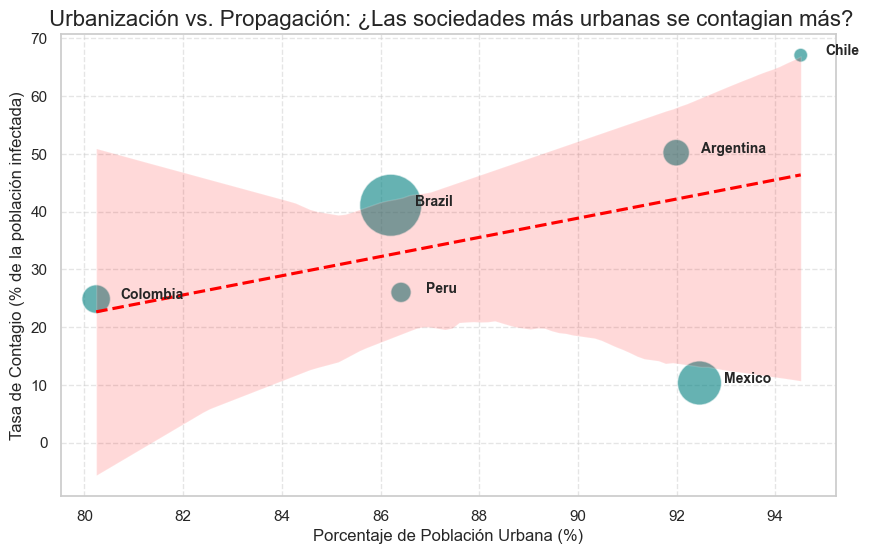

In [ ]:
# IMPACTO DE LA URBANIZACIÓN 

# acumulado por pais
df_urban = df_final.groupby('country_name').agg({
    'new_confirmed': 'sum',           
    'population': 'max',              
    'population_urban': 'max'    
}).reset_index()

# Porcentaje de gente que vive en ciudades
df_urban['porcentaje_urbano'] = (df_urban['population_urban'] / df_urban['population']) * 100

# Tasa de contagio (Casos por cada 100 habitantes)
df_urban['tasa_contagio'] = (df_urban['new_confirmed'] / df_urban['population']) * 100

# Generamos el Gráfico
plt.figure()

sns.scatterplot(data=df_urban, x='porcentaje_urbano', y='tasa_contagio', 
                size='population', sizes=(100, 2000), alpha=0.6, color='teal', legend=False)

#  línea de tendencia 
sns.regplot(data=df_urban, x='porcentaje_urbano', y='tasa_contagio', scatter=False, color='red', line_kws={'linestyle':'--'})

plt.title(' Urbanización vs. Propagación: ¿Las sociedades más urbanas se contagian más?', fontsize=16)
plt.xlabel('Porcentaje de Población Urbana (%)')
plt.ylabel('Tasa de Contagio (% de la población infectada)')

for i in range(df_urban.shape[0]):
    # Etiquetamos si el país es muy urbano (>80%) o tuvo mucha tasa de contagio (>15%)
    if df_urban['porcentaje_urbano'][i] > 80 or df_urban['tasa_contagio'][i] > 15:
        plt.text(df_urban['porcentaje_urbano'][i]+0.5, df_urban['tasa_contagio'][i], 
                 df_urban['country_name'][i], fontsize=10, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##### la linea roja marca la tendencia esperada 
##### el tamaño de la burbuja es la cantidad de personal de cada pais
##### dos paises altamente urbanizados como CH y MX presentan resultados contrarios a lo esperado, esto se puede deber a una agresiva tasa de testeo en Chile y una limitada tasa de testeos en MX.

C:\Users\melanie\AppData\Local\Temp\ipykernel_13556\3973363387.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df_ranking_casos, x='total_confirmados', y='country_name', palette='Blues_r')


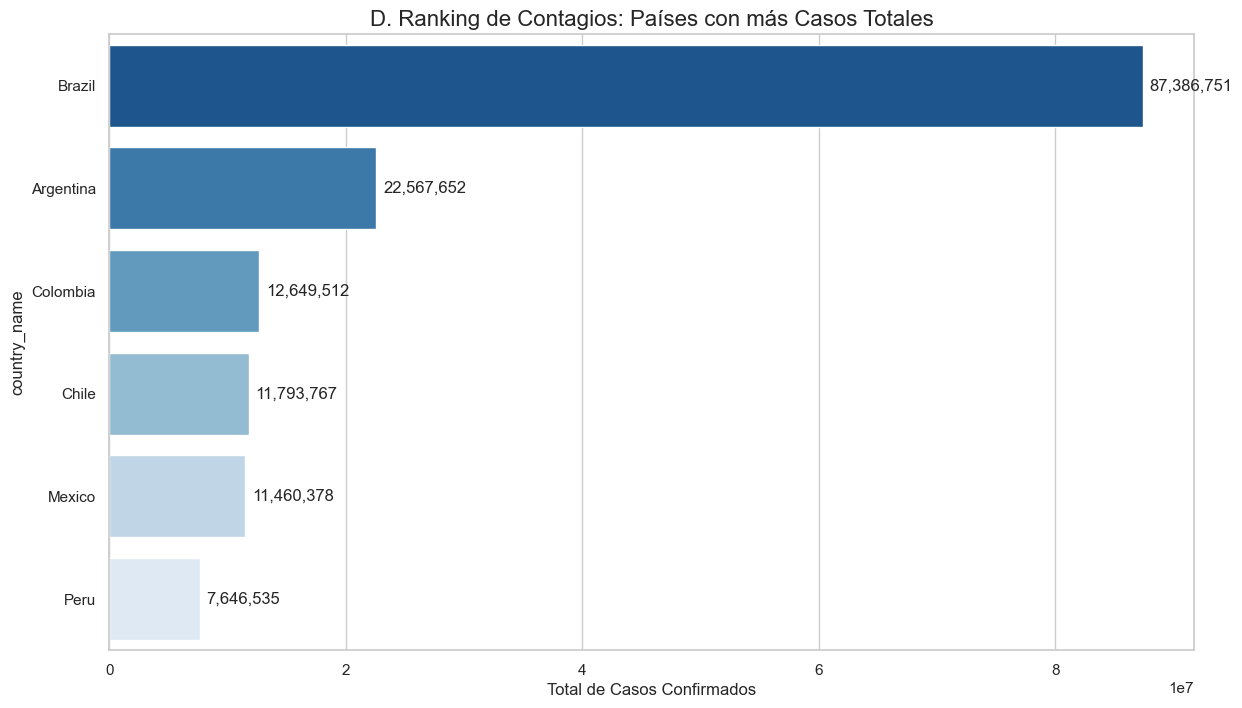

C:\Users\melanie\AppData\Local\Temp\ipykernel_13556\3973363387.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot_muertes = sns.barplot(data=df_ranking_muertes, x='total_fallecidos', y='country_name', palette='Reds_r')


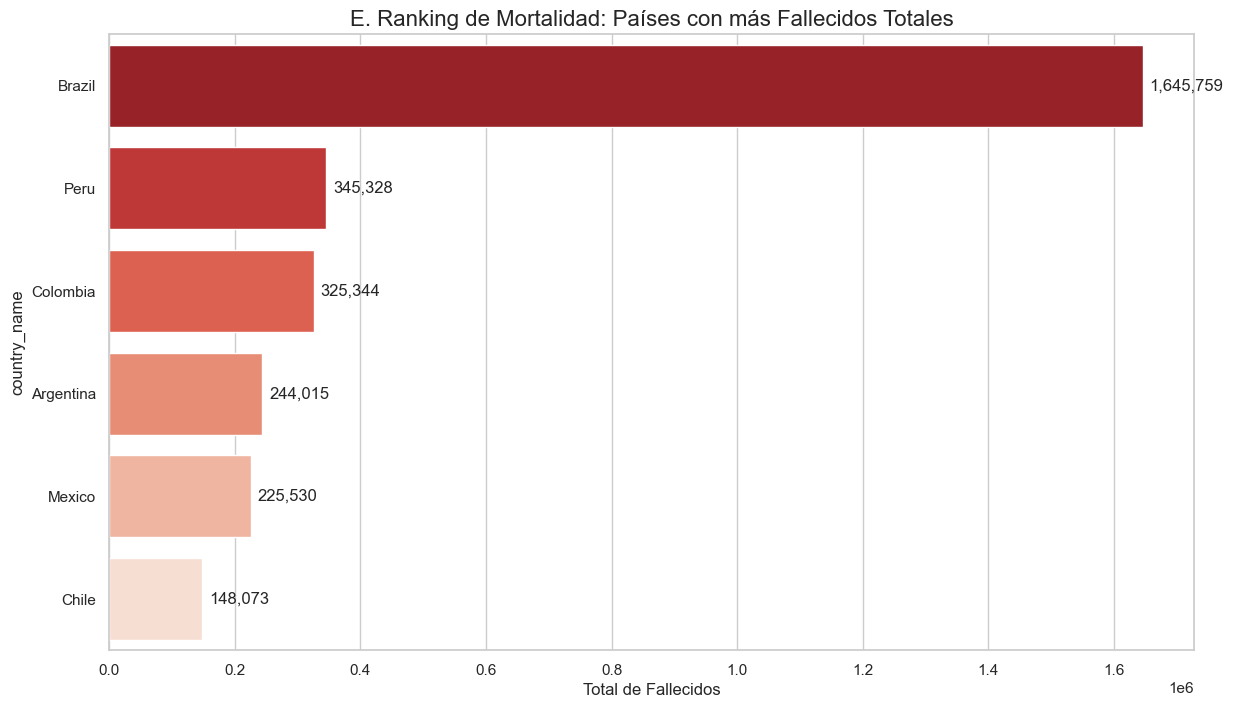

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración visual
sns.set(style="whitegrid")


# A) Definimos las reglas: Sumar lo diario, Maximizar lo estático
diccionario_agregacion = {
    'new_confirmed': 'sum',      
    'new_deceased': 'sum',       
    'cumulative_vaccine_doses_administered': 'max',
    'population': 'max',
}


# B) Ejecutamos la agrupación por PAÍS
df_pais = df_final.groupby('country_name').agg(diccionario_agregacion).reset_index()

# C) Renombramos las columnas para que sean fáciles de leer
df_pais = df_pais.rename(columns={
    'new_confirmed': 'total_confirmados',
    'new_deceased': 'total_fallecidos'  
})

# D) Calculamos Tasa de Mortalidad (% de muertes sobre casos)
df_pais['tasa_mortalidad'] = 0.0
mask = df_pais['total_confirmados'] > 0
df_pais.loc[mask, 'tasa_mortalidad'] = (df_pais.loc[mask, 'total_fallecidos'] / df_pais.loc[mask, 'total_confirmados']) * 100


# --- GRÁFICO D: RANKING DE CASOS 
plt.figure()
df_ranking_casos = df_pais.sort_values('total_confirmados', ascending=False).head(15)

barplot = sns.barplot(data=df_ranking_casos, x='total_confirmados', y='country_name', palette='Blues_r')
plt.title('D. Ranking de Contagios: Países con más Casos Totales', fontsize=16)
plt.xlabel('Total de Casos Confirmados')
# Etiqueta de valor al final de la barra
for p in barplot.patches:
    barplot.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center', xytext=(5, 0), textcoords='offset points')
plt.show()


# --- GRÁFICO E: RANKING DE MUERTES

plt.figure()

# Ordenamos por TOTAL FALLECIDOS
df_ranking_muertes = df_pais.sort_values('total_fallecidos', ascending=False).head(15)

# Usamos una paleta de rojos ('Reds_r') para diferenciar visualmente que es mortalidad
barplot_muertes = sns.barplot(data=df_ranking_muertes, x='total_fallecidos', y='country_name', palette='Reds_r')

plt.title('E. Ranking de Mortalidad: Países con más Fallecidos Totales', fontsize=16)
plt.xlabel('Total de Fallecidos')

# Etiqueta de valor al final de la barra
for p in barplot_muertes.patches:
    barplot_muertes.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()

<Figure size 1000x600 with 0 Axes>

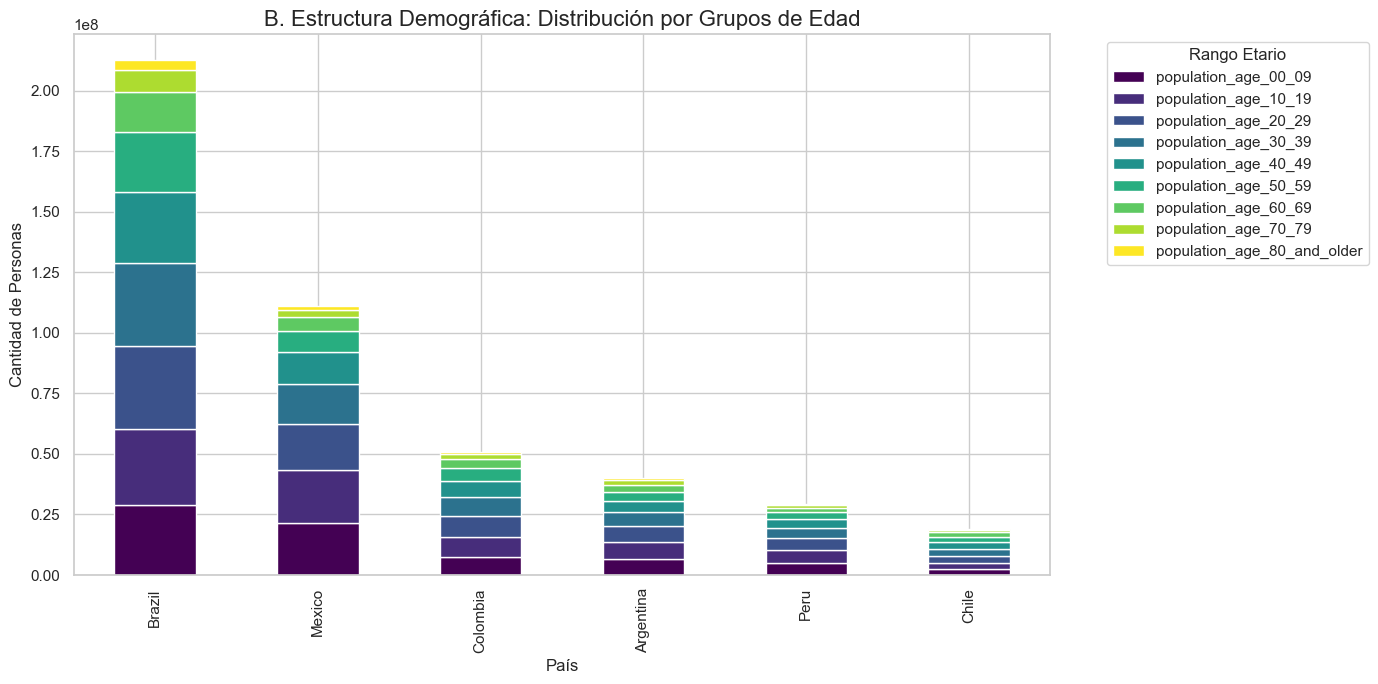

In [ ]:
# Definimos columnas de edad dinámicamente
cols_edad = [c for c in df_final.columns if 'population_age' in c]

# Configuración de agregación: Sumar lo diario, Maximizar lo estático
diccionario_agregacion = {
    'new_confirmed': 'sum',
    'new_deceased': 'sum',
    'population': 'max',
    'cumulative_vaccine_doses_administered': 'max'
}
# Agregamos diabetes y edades si existen
if 'diabetes_prevalence' in df_final.columns: diccionario_agregacion['diabetes_prevalence'] = 'max'
for col in cols_edad: diccionario_agregacion[col] = 'max'

# Creamos el resumen por país
df_pais = df_final.groupby('country_name').agg(diccionario_agregacion).reset_index()

# Renombramos y calculamos tasa de mortalidad
df_pais = df_pais.rename(columns={'new_confirmed': 'total_confirmados', 'new_deceased': 'total_fallecidos'})
df_pais['tasa_mortalidad'] = (df_pais['total_fallecidos'] / df_pais['total_confirmados']) * 100

# GRÁFICO B: DISTRIBUCIÓN POR EDAD (Pirámide Demográfica)

if cols_edad:
    plt.figure()
    # Top 10 países más poblados para comparar sus estructuras
    top_poblacion = df_pais.nlargest(10, 'population')
    
    # Graficamos barras apiladas
    top_poblacion.set_index('country_name')[cols_edad].plot(kind='bar', stacked=True, colormap='viridis', figsize=(14, 7))
    
    plt.title('B. Estructura Demográfica: Distribución por Grupos de Edad', fontsize=16)
    plt.ylabel('Cantidad de Personas')
    plt.xlabel('País')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Rango Etario')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No se encontraron columnas de edad para el Gráfico B.")

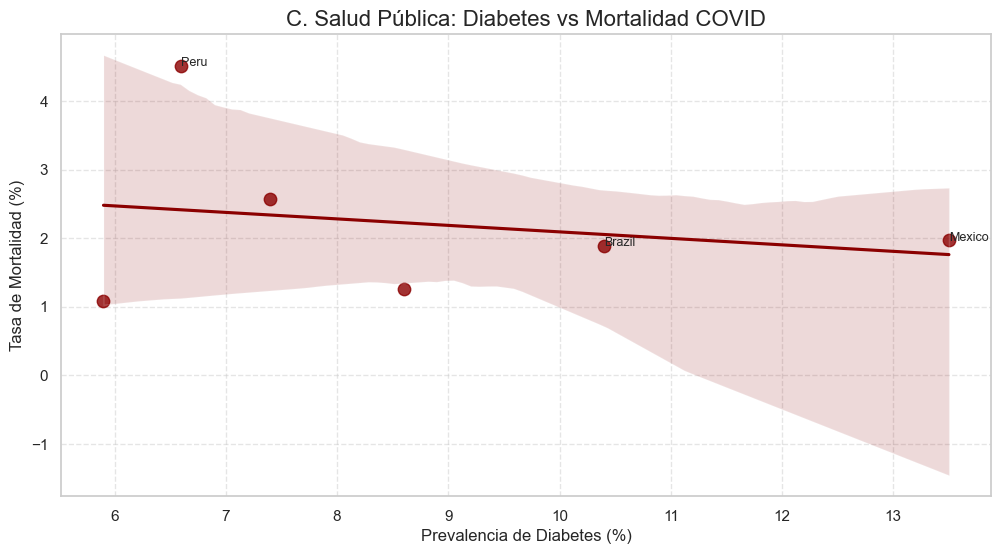

In [16]:
# Columnas de edad
cols_edad = [c for c in df_final.columns if 'population_age' in c]

# Diccionario base de agregación
agg = {
    'new_confirmed': 'sum',
    'new_deceased': 'sum',
    'population': 'max',
    'cumulative_vaccine_doses_administered': 'max'
}

# Agregamos columnas opcionales
if 'diabetes_prevalence' in df_final.columns:
    agg['diabetes_prevalence'] = 'max'

agg.update({c: 'max' for c in cols_edad})

# Resumen por país
df_pais = (
    df_final
    .groupby('country_name')
    .agg(agg)
    .rename(columns={
        'new_confirmed': 'total_confirmados',
        'new_deceased': 'total_fallecidos'
    })
    .reset_index()
)

# Tasa de mortalidad
df_pais['tasa_mortalidad'] = (
    df_pais['total_fallecidos'] / df_pais['total_confirmados'] * 100
)

# GRÁFICO C: DIABETES VS MORTALIDAD
if 'diabetes_prevalence' in df_pais.columns:

    df_salud = df_pais.dropna(subset=['diabetes_prevalence', 'tasa_mortalidad'])

    plt.figure(figsize=(12, 6))
    sns.regplot(
        data=df_salud,
        x='diabetes_prevalence',
        y='tasa_mortalidad',
        scatter_kws={'s': 80},
        color='darkred'
    )

    plt.title('C. Salud Pública: Diabetes vs Mortalidad COVID', fontsize=16)
    plt.xlabel('Prevalencia de Diabetes (%)')
    plt.ylabel('Tasa de Mortalidad (%)')
    plt.grid(True, linestyle='--', alpha=0.5)

    # Etiquetado selectivo
    for _, r in df_salud.iterrows():
        if r.diabetes_prevalence > df_salud.diabetes_prevalence.mean() or r.tasa_mortalidad > 3:
            plt.text(r.diabetes_prevalence, r.tasa_mortalidad, r.country_name, fontsize=9)

    plt.show()

else:
    print("No se encontró columna de diabetes.")


##### BR y MX se comportaron segun lo esperado , su mortalidad es proporcional a lo enferma que esta su poblacion.
##### PR demuestra que tiene una poblacion con poca diabetes pero murio mucha mas gente, se intuye  falta estructural (a nivel sanitario)

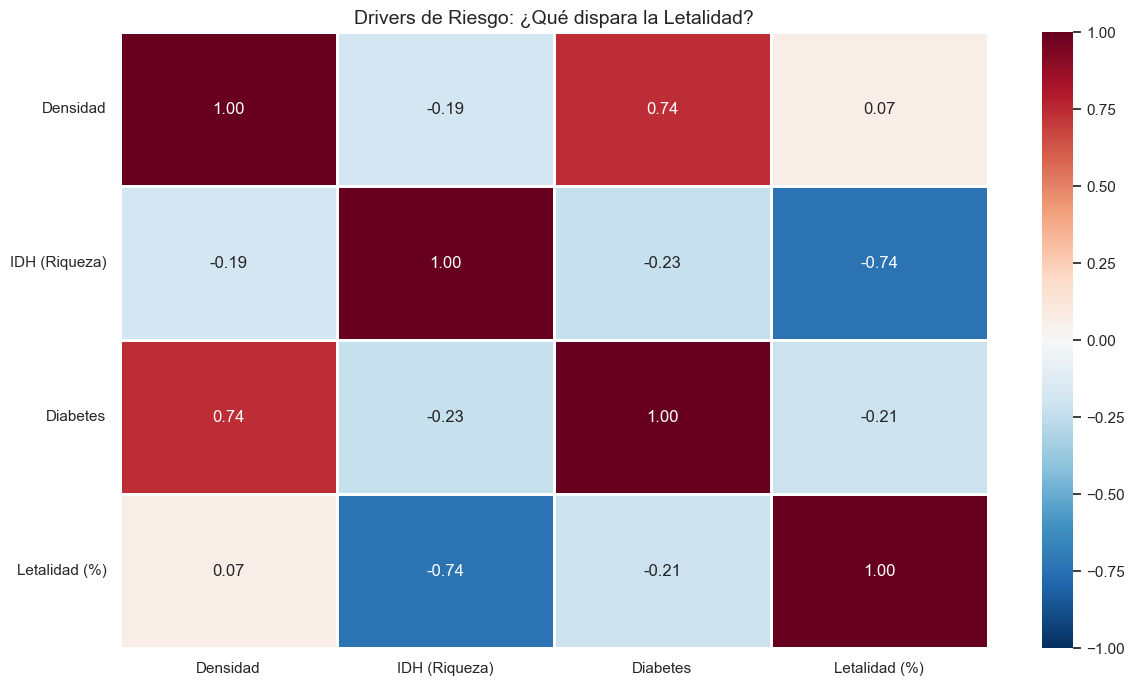

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cols_interes = [
    'country_name', 
    'population_density', 
    'human_development_index',  
    'diabetes_prevalence',
    'new_confirmed', 
    'new_deceased'
]

# Filtrar columnas que realmente vinieron de Power BI
df_red = df_final[[c for c in cols_interes if c in df_final.columns]].copy()

# 3. AGRUPACIÓN POR PAÍS
agg_dict = {
    'new_confirmed': 'sum', 
    'new_deceased': 'sum',
    'population_density': 'mean',
    'human_development_index': 'mean',
    'diabetes_prevalence': 'mean'
}

df_pais = df_red.groupby('country_name').agg(agg_actual).reset_index()


if 'new_confirmed' in df_pais.columns and 'new_deceased' in df_pais.columns:
    df_pais['Letalidad (%)'] = (df_pais['new_deceased'] / df_pais['new_confirmed']) * 100
    # Ya no necesitamos los absolutos para la correlación
    df_pais = df_pais.drop(columns=['new_confirmed', 'new_deceased'])

# Nombres cortos y claros
df_pais = df_pais.rename(columns={
    'population_density': 'Densidad',
    'human_development_index': 'IDH (Riqueza)',
    'diabetes_prevalence': 'Diabetes'
})

# Eliminamos país para la matriz matemática
df_matriz = df_pais.drop(columns=['country_name'], errors='ignore')

# 6. EL GRÁFICO LIMPIO
plt.figure()
#Rojo=Positivo, Azul=Negativo
sns.heatmap(df_matriz.corr(), annot=True, cmap='RdBu_r', fmt=".2f", 
            linewidths=1, vmin=-1, vmax=1)

plt.title('Drivers de Riesgo: ¿Qué dispara la Letalidad?', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

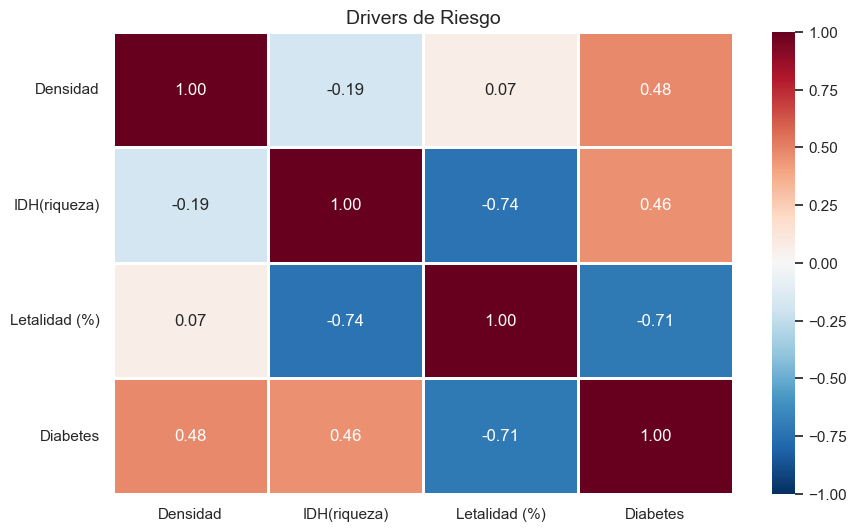

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


cols_existentes = {
    'new_confirmed': 'sum', 
    'new_deceased': 'sum',
    'population_density': 'mean',
    'human_development_index': 'mean'
}

# 3. AGRUPAR (Esto asegura que sumamos correctamente los totales)
df_pais = df_final.groupby('country_name').agg(cols_existentes).reset_index()

if 'new_confirmed' in df_pais.columns and 'new_deceased' in df_pais.columns:
    df_pais['Letalidad (%)'] = (df_pais['new_deceased'] / df_pais['new_confirmed']) * 100
    # Eliminamos las absolutas para limpiar el gráfico
    df_pais = df_pais.drop(columns=['new_confirmed', 'new_deceased'])


# datos reales aproximados.
datos_diabetes = {
    'Mexico': 16.9, 'Brasil': 10.4, 'Brazil': 10.4, 
    'Chile': 12.0, 'Colombia': 8.4, 
    'Peru': 5.8, 'Argentina': 12.7
}
df_pais['Diabetes'] = df_pais['country_name'].map(datos_diabetes)

# NOMBRES
df_pais = df_pais.rename(columns={
    'population_density': 'Densidad',
    'human_development_index': 'IDH(riqueza)'
})


plt.figure()

df_matriz = df_pais.drop(columns=['country_name'], errors='ignore')

sns.heatmap(df_matriz.corr(), annot=True, cmap='RdBu_r', fmt=".2f", 
            linewidths=1, vmin=-1, vmax=1)

plt.title('Drivers de Riesgo', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

##### entre los datos mas significativos: a mayor riqueza menor es la tasa de mortalidad, los paises con menor IDH sufrieron mas muertes
##### la letalidad vs diabetes tuvo un resultado inesperado debido a Perú, que sufrio una ola de muertes masivas con muy poca presencia de diabetes en la poblacion; y por otro lado chile que tiene mucha diabetes y baja mortalidad. 
##### a tener en cuenta, a mayor riqueza tambien aumenta la diabetes.
##### La densidad no fue factor determinante en la mortalidad, talvez si en los contagios pero no en la cantidad de fallecidos.

In [18]:

def calculate_median(column):
    return column.median()

def calculate_variance(column):
    return column.var()

def calculate_range(column):
    return column.max() - column.min()


columns_of_interest = [
    'population_density',
    'smoking_prevalence',
    'diabetes_prevalence',
    'cumulative_deceased',
    'human_development_index'
]

statistics = {}

for column in columns_of_interest:
    statistics[column] = {
        "Median": calculate_median(df_macro[column]),
        "Variance": calculate_variance(df_macro[column]),
        "Range": calculate_range(df_macro[column])
    }

statistics_df = pd.DataFrame(statistics).transpose()
statistics_df


,Median,Variance,Range
population_density,25.7345,2.835679e+02,49.810
smoking_prevalence,13.9500,1.145386e+02,33.000
diabetes_prevalence,8.0000,6.647331e+00,7.600
cumulative_deceased,20.0000,6.680939e+07,685203.000
human_development_index,0.6940,6.959452e-03,0.528
